In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Constants
FREQ_SEC         = 5
HOURLY           = int(3600 / FREQ_SEC)           # 720
DAILY            = int(86400 / FREQ_SEC)          # 17280
FORECAST_HORIZON = int(3 * 3600 / FREQ_SEC)       # 2160  (3-hour horizon)
TEST_DAYS        = 7

In [3]:
df = pd.read_excel("problem_data.xlsx")

# Cleaning and Preprocessing
df = df.dropna(subset="Reading")
df = df.drop_duplicates(subset=['timestamp'], keep='first')
df = df.sort_values('timestamp', ascending=True)

# Resample for missing values
df_5s = df.set_index('timestamp').dropna()
df_5s = df_5s[["Reading"]].resample('5s').sum().reset_index()
df_5s["date"] = df_5s["timestamp"].dt.date
df

,timestamp,Reading
0,2025-09-09 00:00:00,97.72991
1,2025-09-09 00:00:05,88.79527
2,2025-09-09 00:00:10,93.87602
3,2025-09-09 00:00:15,99.95745
4,2025-09-09 00:00:20,112.44842
...,...,...
500703,2025-10-08 23:59:37,1.22197
500704,2025-10-08 23:59:42,1.21763
500705,2025-10-08 23:59:47,1.22272
500706,2025-10-08 23:59:52,1.21639


In [4]:
split_index = int(len(df_5s) - TEST_DAYS * DAILY)
train = df_5s.iloc[:split_index].copy()
test  = df_5s.iloc[split_index:].copy()
print(f"Train: {train.shape}  |  Test: {test.shape}")

Train: (397440, 3)  |  Test: (120960, 3)


In [5]:
# ── Global stats needed for outlier flag ─────────────────────────────────────
GLOBAL_MEAN = train["Reading"].mean()
GLOBAL_STD  = train["Reading"].std()

print(f"\nGlobal mean: {GLOBAL_MEAN:.4f}  |  std: {GLOBAL_STD:.4f}")
print(f"Forecast horizon: {FORECAST_HORIZON} steps = 3 hours")


Global mean: 69.2709  |  std: 47.8259
Forecast horizon: 2160 steps = 3 hours


# Advanced Feature Engineering

In [6]:
def build_features(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    """
    Build the full feature matrix from a time-indexed DataFrame with
    columns ['timestamp', 'Reading'].

    Parameters
    ----------
    df        : DataFrame with 'timestamp' and 'Reading' columns.
    is_train  : If True, drop rows with NaN targets/features (warm-up period).

    Returns
    -------
    DataFrame with feature columns + 'target' column.
    """
    df = df.copy()
    df = df.set_index("timestamp")
    y  = df["Reading"]

    feats = pd.DataFrame(index=df.index)

    # ── 1. Lag features ───────────────────────────────────────────────────────
    lag_steps = [1, 2, 3, 5, 10, 12, 30, 60, 120, 360, 720, 1440, FORECAST_HORIZON]
    for lag in lag_steps:
        feats[f"lag_{lag}"] = y.shift(lag)

    # ── 2. Rolling statistics (min-period prevents NaN cascade) ───────────────
    for win in [12, 60, 360, 720]:
        r = y.shift(1).rolling(window=win, min_periods=max(1, win // 4))
        feats[f"roll_mean_{win}"]   = r.mean()
        feats[f"roll_std_{win}"]    = r.std().fillna(0)
        feats[f"roll_max_{win}"]    = r.max()
        feats[f"roll_min_{win}"]    = r.min()
        feats[f"roll_range_{win}"]  = feats[f"roll_max_{win}"] - feats[f"roll_min_{win}"]

    # ── 3. Exponentially Weighted Mean (alpha ≈ span) ─────────────────────────
    for span in [12, 60, 360]:
        feats[f"ewm_mean_{span}"] = y.shift(1).ewm(span=span, adjust=False).mean()
        feats[f"ewm_std_{span}"]  = y.shift(1).ewm(span=span, adjust=False).std().fillna(0)

    # ── 4. Diff / rate-of-change features ─────────────────────────────────────
    feats["diff_1"]  = y.diff(1).shift(1)   # first difference
    feats["diff_12"] = y.diff(12).shift(1)  # 1-minute change
    feats["diff_60"] = y.diff(60).shift(1)  # 5-minute change

    # ── 5. Cyclical time encodings ────────────────────────────────────────────
    ts = df.index
    feats["hour_sin"]   = np.sin(2 * np.pi * ts.hour / 24)
    feats["hour_cos"]   = np.cos(2 * np.pi * ts.hour / 24)
    feats["minute_sin"] = np.sin(2 * np.pi * ts.minute / 60)
    feats["minute_cos"] = np.cos(2 * np.pi * ts.minute / 60)
    feats["dow_sin"]    = np.sin(2 * np.pi * ts.dayofweek / 7)
    feats["dow_cos"]    = np.cos(2 * np.pi * ts.dayofweek / 7)

    # ── 6. Outage / zero-run indicator ────────────────────────────────────────
    # A zero-run is a structural outage: device not reporting.
    feats["is_zero"]         = (y.shift(1) == 0).astype(int)
    feats["zero_run_length"] = (
        feats["is_zero"]
        .groupby((feats["is_zero"] != feats["is_zero"].shift()).cumsum())
        .cumsum()
    )
    # How many steps since last non-zero? Useful for outage recovery prediction.
    feats["steps_since_nonzero"] = feats["zero_run_length"]

    # ── 7. Local trend via linear regression over last 60 steps ───────────────
    # Approximated cheaply via (roll_mean_60 - roll_mean_12) normalised.
    feats["local_trend"] = (feats["roll_mean_60"] - feats["roll_mean_12"]) / (GLOBAL_STD + 1e-8)

    # ── 8. Target ─────────────────────────────────────────────────────────────
    feats["target"] = y.values   # current Reading is the target

    if is_train:
        # Drop the warm-up rows where long lags are NaN
        max_lag = max(lag_steps)
        feats = feats.iloc[max_lag:]
        feats = feats.dropna()

    return feats.reset_index()


# Build feature matrices
print("Building training feature matrix...")
train_feats = build_features(train, is_train=True)
print(f"  Train features: {train_feats.shape}  |  Columns: {len(train_feats.columns)}")

print("\nBuilding test feature matrix...")
# For test, we also need the tail of train to fill initial lags
# Concatenate, build, then slice back to test only
combined_for_test = pd.concat([
    train[["timestamp", "Reading"]].iloc[-(FORECAST_HORIZON + 100):],
    test[["timestamp", "Reading"]]
], ignore_index=True)
test_feats_full = build_features(combined_for_test, is_train=False)

# Keep only rows whose timestamps fall in the test period
test_start_ts = test["timestamp"].iloc[0]
test_feats = test_feats_full[test_feats_full["timestamp"] >= test_start_ts].copy()
print(f"  Test features : {test_feats.shape}")


Building training feature matrix...
  Train features: (395280, 54)  |  Columns: 54

Building test feature matrix...
  Test features : (120960, 54)


In [7]:
# ── Feature sanity check ──────────────────────────────────────────────────────
FEATURE_COLS = [c for c in train_feats.columns if c not in ("timestamp", "target")]

print(f"Total features  : {len(FEATURE_COLS)}")
print(f"Feature names   : {FEATURE_COLS[:10]} ...")
print()
print("Missing values in train features:")
missing = train_feats[FEATURE_COLS].isna().sum()
print(missing[missing > 0] if missing.any() else "  None — all clean.")
print()
train_feats[FEATURE_COLS].describe().T[["mean","std","min","max"]].round(3).head(20)


Total features  : 52
Feature names   : ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'lag_12', 'lag_30', 'lag_60', 'lag_120', 'lag_360'] ...

Missing values in train features:
  None — all clean.



,mean,std,min,max
lag_1,69.145,47.836,0.0,252.554
lag_2,69.145,47.836,0.0,252.554
lag_3,69.144,47.836,0.0,252.554
lag_5,69.144,47.837,0.0,252.554
lag_10,69.143,47.837,0.0,252.554
lag_12,69.142,47.837,0.0,252.554
lag_30,69.138,47.839,0.0,252.554
lag_60,69.131,47.841,0.0,252.554
lag_120,69.127,47.841,0.0,252.554
lag_360,69.129,47.842,0.0,252.554


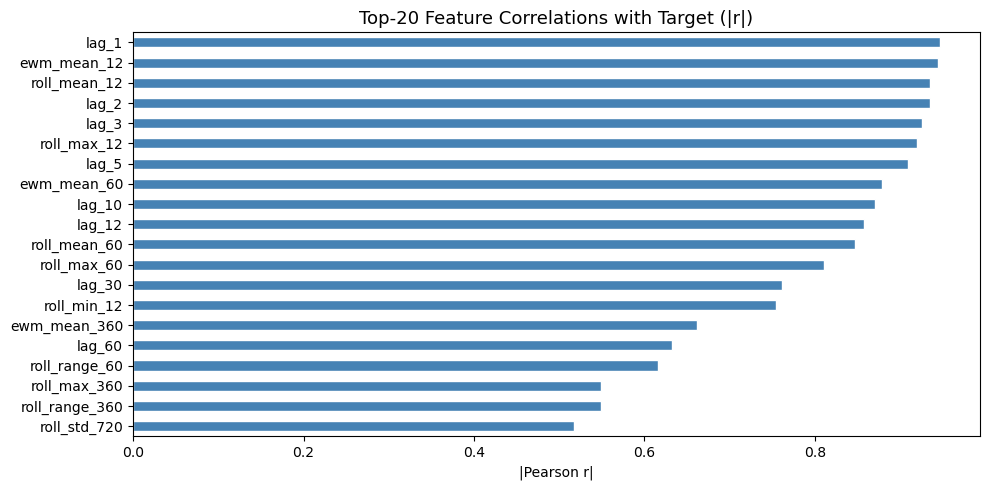

In [8]:
# ── Feature correlation with target ──────────────────────────────────────────
corr = train_feats[FEATURE_COLS + ["target"]].corr()["target"].drop("target")
top_corr = corr.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
top_corr.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top-20 Feature Correlations with Target (|r|)", fontsize=13)
ax.set_xlabel("|Pearson r|")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# ML Model training

In [9]:
from collections import deque

class RecursiveForecaster:
    """
    Wraps any sklearn-compatible regressor for recursive multi-step forecasting.

    The approach:
      - Maintains a rolling buffer of recent actuals + predictions.
      - At each step, recomputes only the stateful features (lags, rolling,
        EWM) from the buffer without rebuilding the full DataFrame.
      - Cyclical / time features are computed directly from the timestamp.

    Parameters
    ----------
    model         : Fitted sklearn-compatible model with .predict(X).
    feature_cols  : List of feature names matching model's training columns.
    history_vals  : np.array of recent actual values (at least max-lag length).
    history_ts    : pd.DatetimeIndex matching history_vals.
    freq          : pd.Timedelta — step size (5 seconds here).
    global_std    : float — used for local_trend normalisation.
    """

    LAG_STEPS    = [1, 2, 3, 5, 10, 12, 30, 60, 120, 360, 720, 1440, FORECAST_HORIZON]
    ROLL_WINDOWS = [12, 60, 360, 720]
    EWM_SPANS    = [12, 60, 360]
    DIFF_STEPS   = [1, 12, 60]

    def __init__(self, model, feature_cols, history_vals, history_ts,
                 freq=pd.Timedelta("5s"), global_std=1.0):
        self.model        = model
        self.feature_cols = feature_cols
        self.freq         = freq
        self.global_std   = global_std

        max_lag      = max(self.LAG_STEPS)
        max_roll     = max(self.ROLL_WINDOWS)
        self.buf_len = max(max_lag, max_roll) + 10

        # Circular buffer — oldest first
        self.buf_vals = deque(history_vals[-self.buf_len:], maxlen=self.buf_len)
        self.buf_ts   = deque(history_ts[-self.buf_len:], maxlen=self.buf_len)

        # EWM state: maintained incrementally
        self._ewm_mean = {}
        self._ewm_var  = {}
        for span in self.EWM_SPANS:
            alpha = 2 / (span + 1)
            # Initialise from history
            m = float(np.mean(list(self.buf_vals)))
            self._ewm_mean[span] = m
            self._ewm_var[span]  = float(np.var(list(self.buf_vals)))
            self._alpha = {s: 2 / (s + 1) for s in self.EWM_SPANS}

    def _update_ewm(self, new_val):
        for span in self.EWM_SPANS:
            a = self._alpha[span]
            self._ewm_mean[span] = a * new_val + (1 - a) * self._ewm_mean[span]
            self._ewm_var[span]  = (1 - a) * (self._ewm_var[span] +
                                    a * (new_val - self._ewm_mean[span]) ** 2)

    def _build_row(self, next_ts: pd.Timestamp) -> np.ndarray:
        buf = np.array(self.buf_vals)   # oldest … newest

        row = {}

        # ── Lags ─────────────────────────────────────────────────────────────
        for lag in self.LAG_STEPS:
            idx = -(lag)
            row[f"lag_{lag}"] = buf[idx] if len(buf) >= lag else 0.0

        # ── Rolling stats ─────────────────────────────────────────────────────
        for win in self.ROLL_WINDOWS:
            window_vals = buf[-win:] if len(buf) >= win else buf
            row[f"roll_mean_{win}"]  = float(np.mean(window_vals))
            row[f"roll_std_{win}"]   = float(np.std(window_vals))
            row[f"roll_max_{win}"]   = float(np.max(window_vals))
            row[f"roll_min_{win}"]   = float(np.min(window_vals))
            row[f"roll_range_{win}"] = row[f"roll_max_{win}"] - row[f"roll_min_{win}"]

        # ── EWM ───────────────────────────────────────────────────────────────
        for span in self.EWM_SPANS:
            row[f"ewm_mean_{span}"] = self._ewm_mean[span]
            row[f"ewm_std_{span}"]  = float(np.sqrt(max(self._ewm_var[span], 0)))

        # ── Diffs ─────────────────────────────────────────────────────────────
        for d in self.DIFF_STEPS:
            row[f"diff_{d}"] = float(buf[-1] - buf[-d-1]) if len(buf) > d else 0.0

        # ── Cyclical time ─────────────────────────────────────────────────────
        row["hour_sin"]   = np.sin(2 * np.pi * next_ts.hour / 24)
        row["hour_cos"]   = np.cos(2 * np.pi * next_ts.hour / 24)
        row["minute_sin"] = np.sin(2 * np.pi * next_ts.minute / 60)
        row["minute_cos"] = np.cos(2 * np.pi * next_ts.minute / 60)
        row["dow_sin"]    = np.sin(2 * np.pi * next_ts.dayofweek / 7)
        row["dow_cos"]    = np.cos(2 * np.pi * next_ts.dayofweek / 7)

        # ── Outage indicator ──────────────────────────────────────────────────
        row["is_zero"]            = int(buf[-1] == 0)
        zero_run = 0
        for v in reversed(list(self.buf_vals)):
            if v == 0: zero_run += 1
            else: break
        row["zero_run_length"]    = zero_run
        row["steps_since_nonzero"] = zero_run

        # ── Local trend ───────────────────────────────────────────────────────
        row["local_trend"] = (row["roll_mean_60"] - row["roll_mean_12"]) / (self.global_std + 1e-8)

        return np.array([row[c] for c in self.feature_cols], dtype=np.float32)

    def forecast(self, n_steps: int, start_ts: pd.Timestamp) -> np.ndarray:
        """Generate n_steps recursive predictions starting at start_ts."""
        preds = np.empty(n_steps, dtype=np.float32)
        cur_ts = start_ts

        for i in range(n_steps):
            x_row = self._build_row(cur_ts).reshape(1, -1)
            pred  = float(self.model.predict(x_row)[0])
            pred  = max(pred, 0.0)          # device readings are non-negative
            preds[i] = pred

            self._update_ewm(pred)
            self.buf_vals.append(pred)
            self.buf_ts.append(cur_ts)
            cur_ts += self.freq

        return preds


print("RecursiveForecaster class defined.")


RecursiveForecaster class defined.


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_leaderboard = []   # global registry

def smape(y_true, y_pred):
    """Symmetric MAPE — bounded [0,200], robust to near-zero values."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask  = denom > 0
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100)

def mase(y_true, y_pred, y_train, m=1):
    """Mean Absolute Scaled Error relative to naive seasonal (lag-m) baseline."""
    y_true, y_pred, y_train = map(np.array, [y_true, y_pred, y_train])
    mae_model   = mean_absolute_error(y_true, y_pred)
    naive_errors = np.abs(np.diff(y_train, n=m))
    mae_naive   = np.mean(naive_errors) if len(naive_errors) > 0 else 1.0
    return float(mae_model / (mae_naive + 1e-8))

def evaluate_ml(y_true, y_pred, model_name, y_train=None):
    """Compute and print all metrics; append to global leaderboard."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]

    mae  = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    s    = smape(y_true, y_pred)
    m    = mase(y_true, y_pred, y_train) if y_train is not None else np.nan

    nz = y_true != 0
    mape = float(np.mean(np.abs((y_true[nz]-y_pred[nz])/y_true[nz]))*100) if nz.any() else np.nan

    result = dict(Model=model_name, MAE=mae, RMSE=rmse, SMAPE=s, MASE=m, MAPE=mape)
    model_leaderboard.append(result)

    print(f"\n{'─'*40}")
    print(f"  {model_name}")
    print(f"{'─'*40}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  SMAPE : {s:.2f}%")
    print(f"  MASE  : {m:.4f}" if not np.isnan(m) else "  MASE  : N/A")
    print(f"  MAPE  : {mape:.2f}%" if not np.isnan(mape) else "  MAPE  : N/A (zero actuals)")

    return result

def plot_forecast(y_true, y_pred, model_name, n_show=2160):
    """Plot actual vs predicted for the first n_show test steps."""
    n = min(n_show, len(y_true), len(y_pred))
    fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                             gridspec_kw={"height_ratios": [3, 1]})

    axes[0].plot(y_true[:n],  label="Actual",    alpha=0.7, linewidth=0.8)
    axes[0].plot(y_pred[:n],  label="Predicted", alpha=0.85, linewidth=0.9, color="tomato")
    axes[0].set_title(f"{model_name} — Actual vs Predicted (first {n} test steps)", fontsize=12)
    axes[0].legend()
    axes[0].set_ylabel("Reading")

    residuals = np.array(y_true[:n]) - np.array(y_pred[:n])
    axes[1].bar(range(n), residuals, alpha=0.4, color="steelblue", width=1)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Residuals (Actual − Predicted)")
    axes[1].set_ylabel("Residual")
    axes[1].set_xlabel("Step")

    plt.tight_layout()
    plt.show()


print("Evaluation utilities defined.")


Evaluation utilities defined.


### 1. XGBoost Regressor

In [11]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

X_train = train_feats[FEATURE_COLS].values.astype(np.float32)
y_train = train_feats["target"].values.astype(np.float32)

X_test  = test_feats[FEATURE_COLS].values.astype(np.float32)
y_test  = test_feats["target"].values.astype(np.float32)

# ── Walk-forward validation split (last 20% of train as val) ─────────────────
val_size  = int(0.2 * len(X_train))
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

print(f"XGBoost — Train: {X_tr.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")

xgb_model = XGBRegressor(
    n_estimators       = 800,
    max_depth          = 7,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 10,       # avoids splits on tiny groups (noise-robust)
    reg_alpha          = 0.1,      # L1
    reg_lambda         = 1.0,      # L2
    tree_method        = "hist",   # fast histogram-based algorithm
    random_state       = 42,
    early_stopping_rounds = 30,
    eval_metric        = "mae",
    verbosity          = 0,
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set      = [(X_val, y_val)],
    verbose       = 100,
)

print(f"\nBest iteration: {xgb_model.best_iteration}")


XGBoost — Train: (316224, 52)  |  Val: (79056, 52)  |  Test: (120960, 52)
[0]	validation_0-mae:46.39602
[100]	validation_0-mae:4.47888
[200]	validation_0-mae:4.56070
[203]	validation_0-mae:4.56088

Best iteration: 173



────────────────────────────────────────
  XGBoost (1-step, no recursion)
────────────────────────────────────────
  MAE   : 6.0438
  RMSE  : 13.4877
  SMAPE : 27.28%
  MASE  : 0.9445
  MAPE  : 15.05%

Running XGBoost recursive 3-hour forecast...

────────────────────────────────────────
  XGBoost (Recursive 3-hr)
────────────────────────────────────────
  MAE   : 41.0126
  RMSE  : 44.8648
  SMAPE : 90.81%
  MASE  : 6.4094
  MAPE  : 388.72%


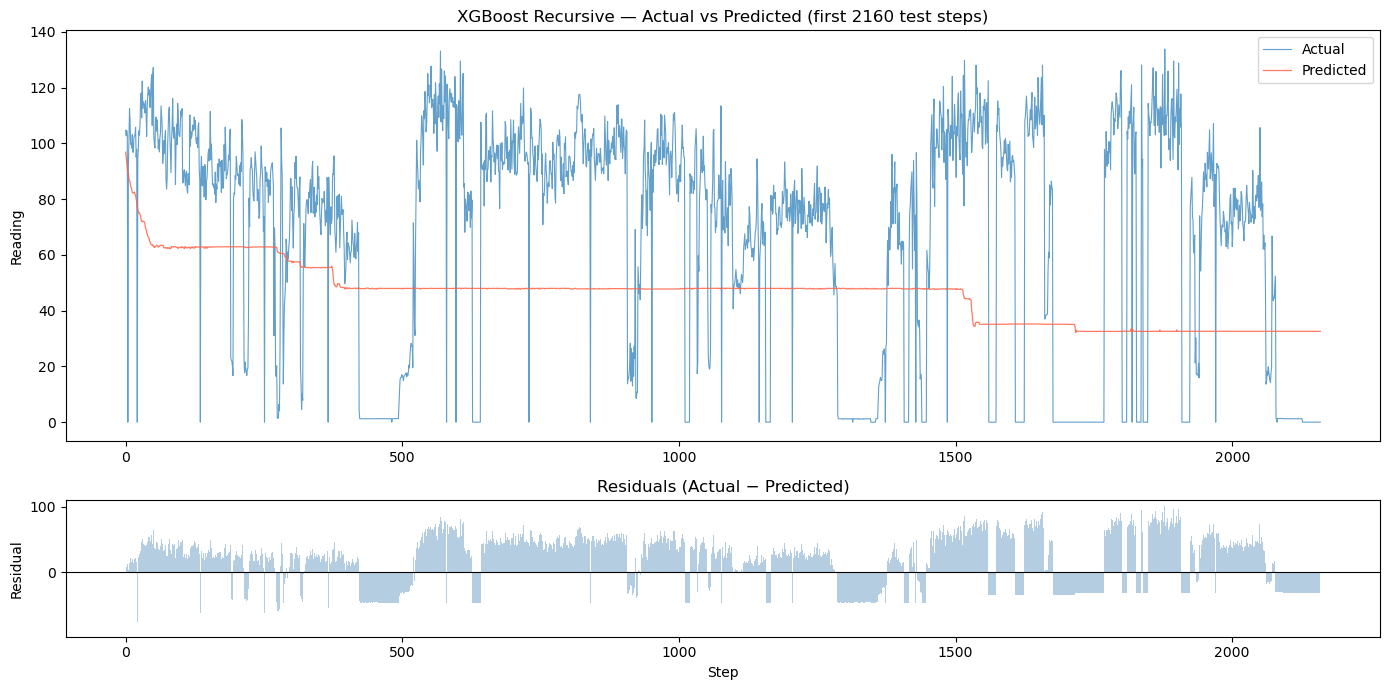

In [12]:
# ── One-step-ahead evaluation (upper bound — no error accumulation) ───────────
xgb_1step_preds = xgb_model.predict(X_test)
evaluate_ml(y_test, xgb_1step_preds, "XGBoost (1-step, no recursion)", y_train)

# ── Recursive 3-hour forecast ─────────────────────────────────────────────────
print("\nRunning XGBoost recursive 3-hour forecast...")

history_vals = train["Reading"].values
history_ts   = train["timestamp"].values

xgb_forecaster = RecursiveForecaster(
    model        = xgb_model,
    feature_cols = FEATURE_COLS,
    history_vals = history_vals,
    history_ts   = pd.DatetimeIndex(history_ts),
    global_std   = GLOBAL_STD,
)

xgb_recursive_preds = xgb_forecaster.forecast(
    n_steps  = FORECAST_HORIZON,
    start_ts = test["timestamp"].iloc[0],
)

xgb_result = evaluate_ml(
    y_test[:FORECAST_HORIZON],
    xgb_recursive_preds,
    "XGBoost (Recursive 3-hr)",
    y_train,
)

plot_forecast(y_test, xgb_recursive_preds, "XGBoost Recursive")


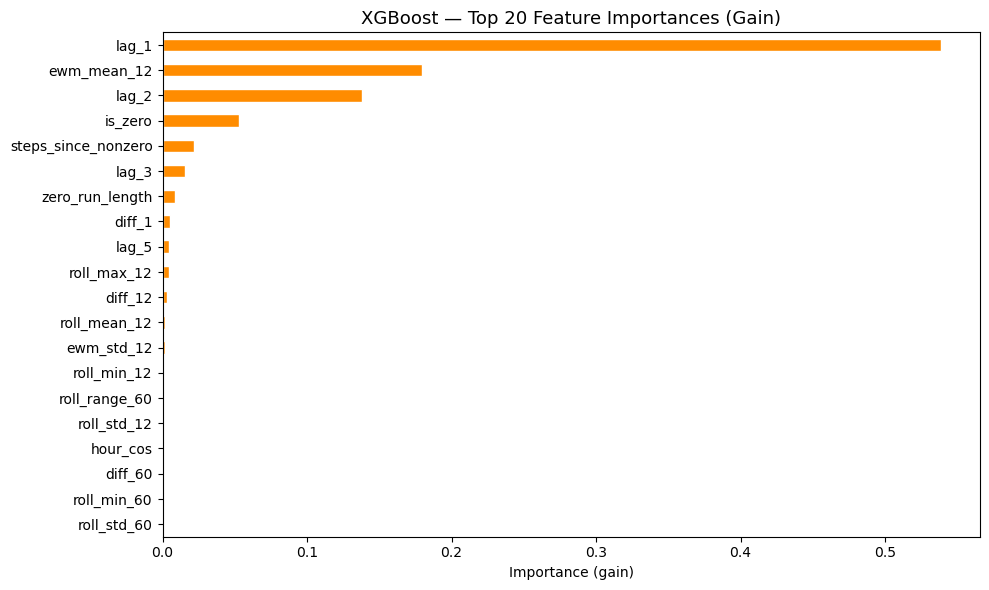

In [13]:
# ── Feature importance ────────────────────────────────────────────────────────
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.plot.barh(ax=ax, color="darkorange", edgecolor="white")
ax.set_title("XGBoost — Top 20 Feature Importances (Gain)", fontsize=13)
ax.set_xlabel("Importance (gain)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 2. LightGBM Regressor

In [14]:
from lightgbm import LGBMRegressor
import lightgbm as lgb

lgb_model = LGBMRegressor(
    n_estimators       = 800,
    num_leaves         = 63,        # 2^6 - 1; good default for tabular TS
    max_depth          = -1,        # unconstrained with num_leaves guard
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_samples  = 20,        # min samples per leaf
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    random_state       = 42,
    n_jobs             = -1,
    verbosity          = -1,
)

lgb_callbacks = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(100)]

lgb_model.fit(
    X_tr, y_tr,
    eval_set    = [(X_val, y_val)],
    callbacks   = lgb_callbacks,
)

print(f"Best iteration: {lgb_model.best_iteration_}")


[100]	valid_0's l2: 112.835
Best iteration: 136



────────────────────────────────────────
  LightGBM (1-step, no recursion)
────────────────────────────────────────
  MAE   : 6.0936
  RMSE  : 13.5149
  SMAPE : 27.47%
  MASE  : 0.9523
  MAPE  : 15.62%

Running LightGBM recursive 3-hour forecast...


c:\Users\prafu\.conda\envs\company_projects_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\prafu\.conda\envs\company_projects_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\prafu\.conda\envs\company_projects_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\prafu\.conda\envs\company_projects_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\prafu\.conda\envs\company_projects_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featu


────────────────────────────────────────
  LightGBM (Recursive 3-hr)
────────────────────────────────────────
  MAE   : 38.4653
  RMSE  : 42.0518
  SMAPE : 79.45%
  MASE  : 6.0113
  MAPE  : 481.44%


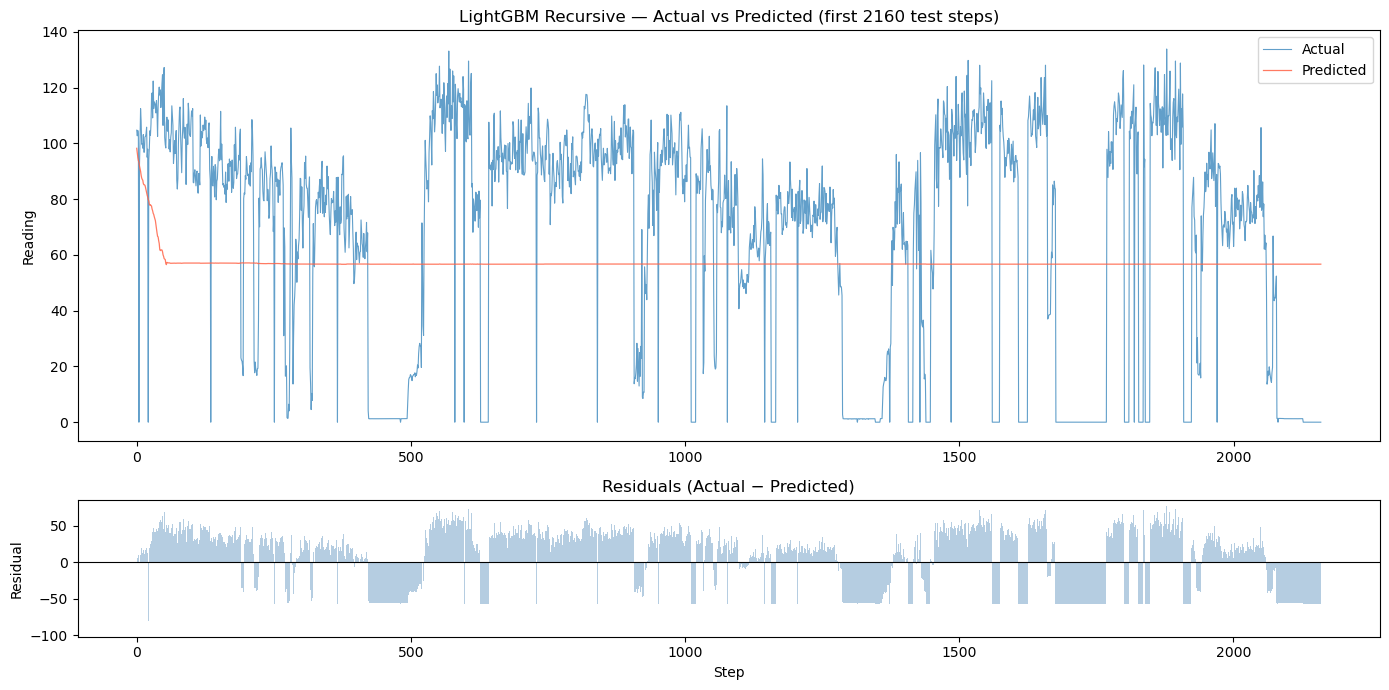

In [15]:
# ── 1-step evaluation ─────────────────────────────────────────────────────────
lgb_1step_preds = lgb_model.predict(X_test)
evaluate_ml(y_test, lgb_1step_preds, "LightGBM (1-step, no recursion)", y_train)

# ── Recursive forecast ────────────────────────────────────────────────────────
print("\nRunning LightGBM recursive 3-hour forecast...")

lgb_forecaster = RecursiveForecaster(
    model        = lgb_model,
    feature_cols = FEATURE_COLS,
    history_vals = history_vals,
    history_ts   = pd.DatetimeIndex(history_ts),
    global_std   = GLOBAL_STD,
)

lgb_recursive_preds = lgb_forecaster.forecast(
    n_steps  = FORECAST_HORIZON,
    start_ts = test["timestamp"].iloc[0],
)

lgb_result = evaluate_ml(
    y_test[:FORECAST_HORIZON],
    lgb_recursive_preds,
    "LightGBM (Recursive 3-hr)",
    y_train,
)

plot_forecast(y_test, lgb_recursive_preds, "LightGBM Recursive")


### 3. Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Subsample for speed — RF scales O(n * n_estimators * max_features * depth)
subsample_frac = 0.3
n_sub = int(len(X_tr) * subsample_frac)
idx   = np.random.RandomState(42).choice(len(X_tr), n_sub, replace=False)
X_tr_sub, y_tr_sub = X_tr[idx], y_tr[idx]

print(f"RF training on {X_tr_sub.shape[0]:,} samples (subsample)")

rf_model = RandomForestRegressor(
    n_estimators = 200,
    max_depth    = 15,
    min_samples_leaf = 10,
    max_features = 0.5,
    n_jobs       = -1,
    random_state = 42,
)
rf_model.fit(X_tr_sub, y_tr_sub)
print("Random Forest fitted.")


RF training on 94,867 samples (subsample)
Random Forest fitted.



────────────────────────────────────────
  RandomForest (1-step, no recursion)
────────────────────────────────────────
  MAE   : 5.9052
  RMSE  : 13.4415
  SMAPE : 23.64%
  MASE  : 0.9229
  MAPE  : 14.59%

Running RandomForest recursive 3-hour forecast...

────────────────────────────────────────
  RandomForest (Recursive 3-hr)
────────────────────────────────────────
  MAE   : 46.4039
  RMSE  : 49.9814
  SMAPE : 103.58%
  MASE  : 7.2520
  MAPE  : 325.96%


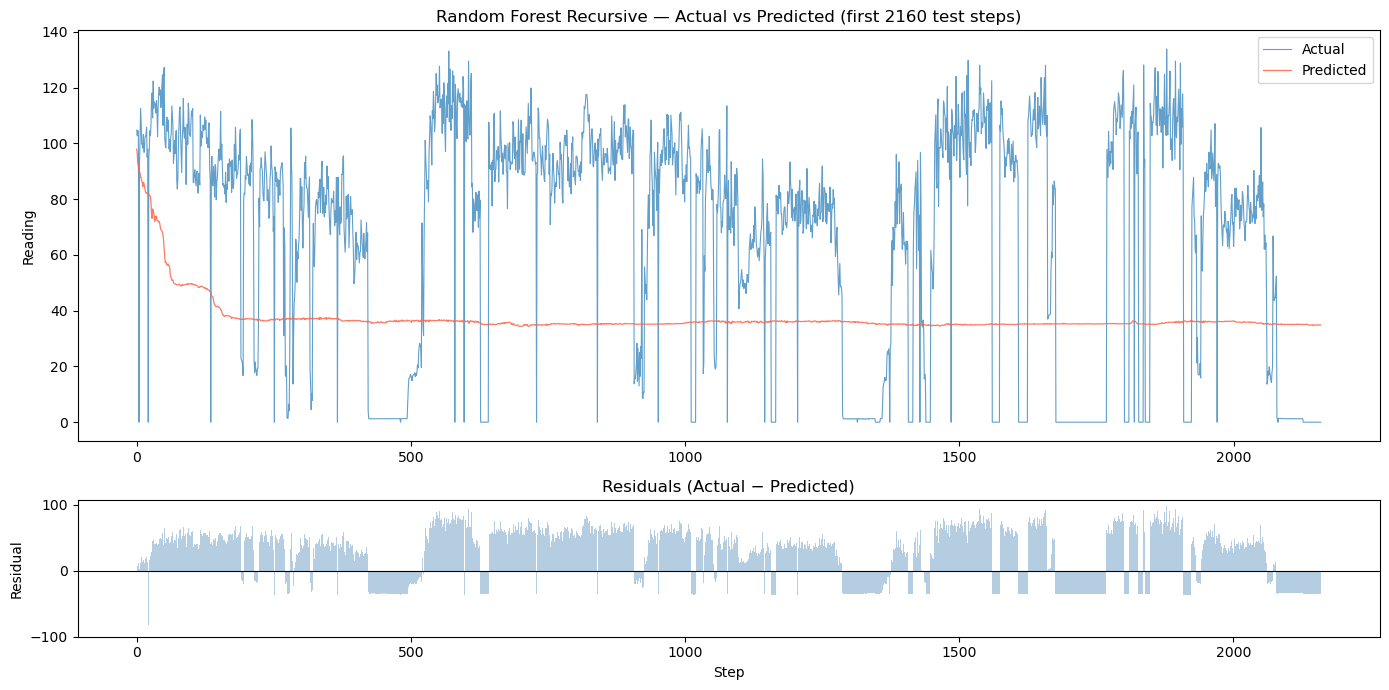

In [17]:
rf_1step_preds = rf_model.predict(X_test)
evaluate_ml(y_test, rf_1step_preds, "RandomForest (1-step, no recursion)", y_train)

print("\nRunning RandomForest recursive 3-hour forecast...")
rf_forecaster = RecursiveForecaster(
    model        = rf_model,
    feature_cols = FEATURE_COLS,
    history_vals = history_vals,
    history_ts   = pd.DatetimeIndex(history_ts),
    global_std   = GLOBAL_STD,
)

rf_recursive_preds = rf_forecaster.forecast(
    n_steps  = FORECAST_HORIZON,
    start_ts = test["timestamp"].iloc[0],
)

rf_result = evaluate_ml(
    y_test[:FORECAST_HORIZON],
    rf_recursive_preds,
    "RandomForest (Recursive 3-hr)",
    y_train,
)

plot_forecast(y_test, rf_recursive_preds, "Random Forest Recursive")


# Compare all models

In [18]:
# ── Model leaderboard ─────────────────────────────────────────────────────────
leaderboard_df = (
    pd.DataFrame(model_leaderboard)
    .sort_values("SMAPE")
    .reset_index(drop=True)
)
leaderboard_df.index += 1   # 1-indexed ranking

print("\n===== MODEL LEADERBOARD (sorted by SMAPE) =====")
print(leaderboard_df.to_string(index=True))



===== MODEL LEADERBOARD (sorted by SMAPE) =====
                                 Model        MAE       RMSE       SMAPE      MASE        MAPE
1  RandomForest (1-step, no recursion)   5.905160  13.441540   23.644284  0.922854   14.586203
2       XGBoost (1-step, no recursion)   6.043775  13.487670   27.278004  0.944517   15.054980
3      LightGBM (1-step, no recursion)   6.093568  13.514901   27.471080  0.952299   15.620460
4            LightGBM (Recursive 3-hr)  38.465267  42.051822   79.453102  6.011326  481.439026
5             XGBoost (Recursive 3-hr)  41.012623  44.864839   90.811653  6.409425  388.719604
6        RandomForest (Recursive 3-hr)  46.403885  49.981381  103.578720  7.251967  325.958710


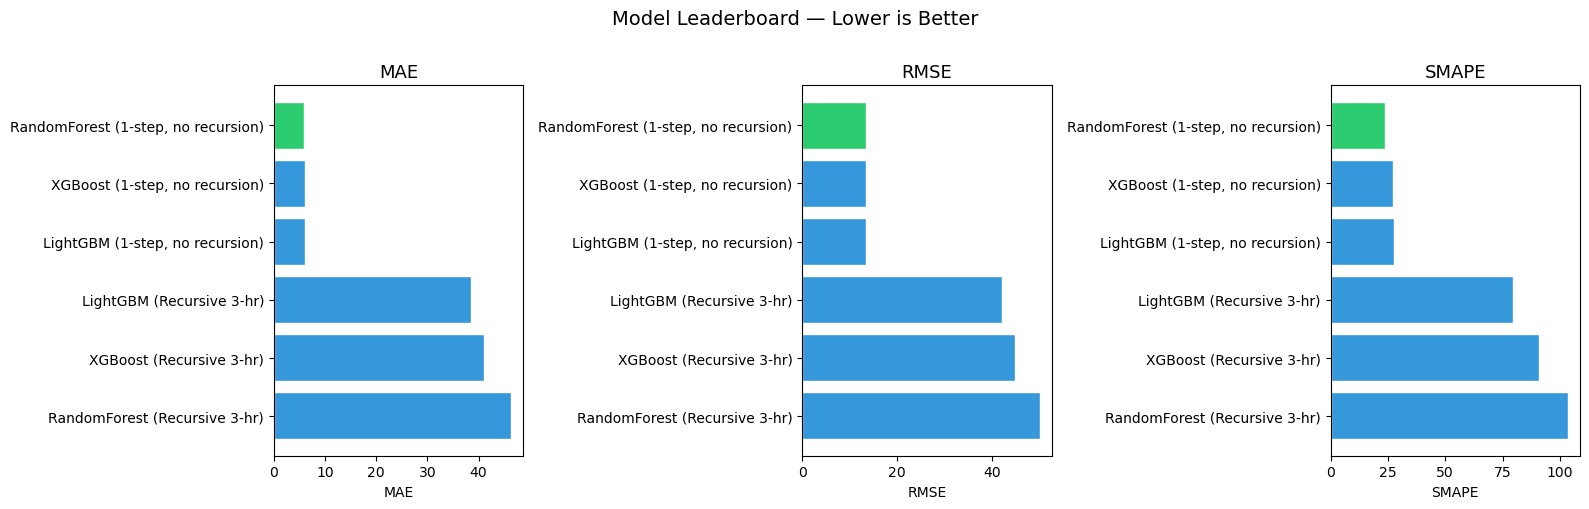

In [19]:
# ── Visual leaderboard ────────────────────────────────────────────────────────
metrics = ["MAE", "RMSE", "SMAPE"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    sub = leaderboard_df[leaderboard_df[metric].notna()].copy()
    colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(sub))]
    ax.barh(sub["Model"], sub[metric], color=colors, edgecolor="white")
    ax.set_title(metric, fontsize=13)
    ax.invert_yaxis()
    ax.set_xlabel(metric)

plt.suptitle("Model Leaderboard — Lower is Better", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


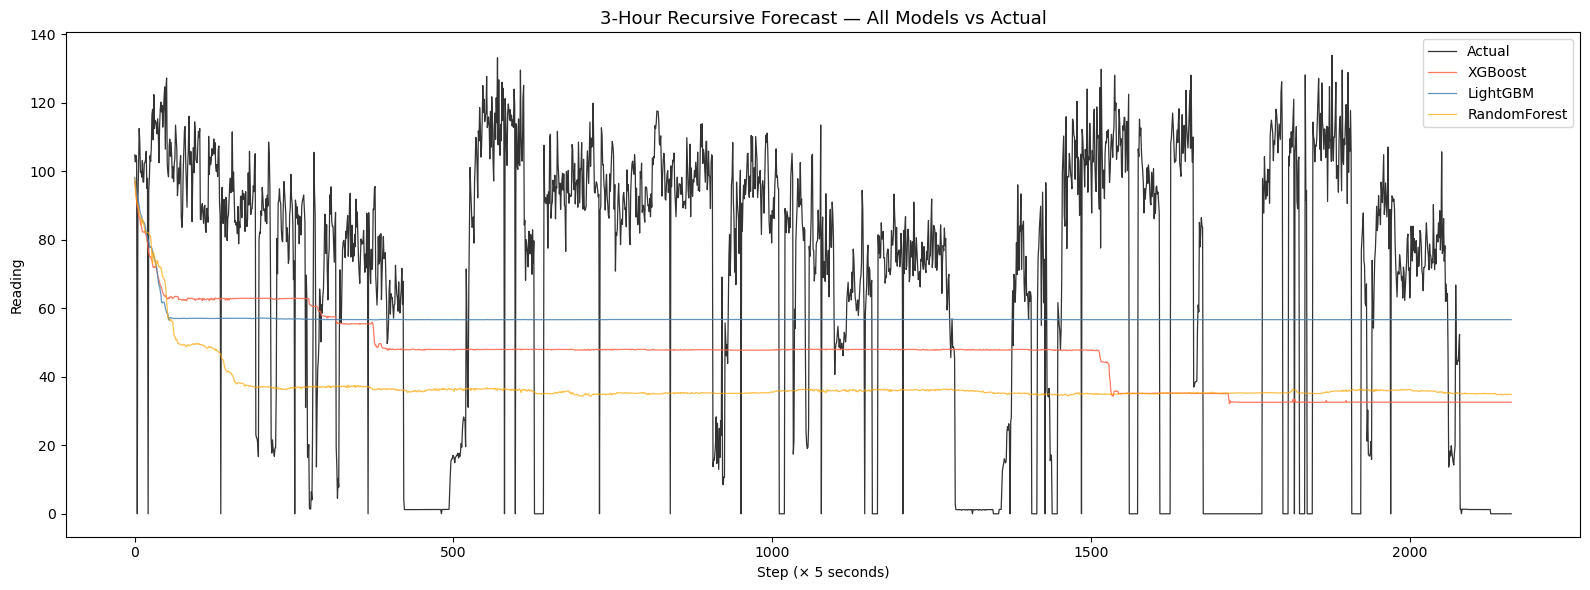

In [20]:
# ── Side-by-side forecast comparison ─────────────────────────────────────────
n_show = min(FORECAST_HORIZON, len(y_test))
t_axis = np.arange(n_show)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(t_axis, y_test[:n_show],         label="Actual",         linewidth=0.9, alpha=0.8, color="black")
ax.plot(t_axis, xgb_recursive_preds[:n_show], label="XGBoost",  linewidth=0.9, alpha=0.85, color="tomato")
ax.plot(t_axis, lgb_recursive_preds[:n_show], label="LightGBM", linewidth=0.9, alpha=0.85, color="steelblue")
ax.plot(t_axis, rf_recursive_preds[:n_show],  label="RandomForest", linewidth=0.9, alpha=0.7, color="orange")

ax.set_title("3-Hour Recursive Forecast — All Models vs Actual", fontsize=13)
ax.set_xlabel("Step (× 5 seconds)")
ax.set_ylabel("Reading")
ax.legend()
plt.tight_layout()
plt.show()
